# CNN Image Classification — Benchmark Model

This notebook implements the **CNN** part of the assignment:
- load the **CIFAR-10** dataset (reusing baseline config)
- implement **CNN** (Conv2d, BatchNorm, ReLU, MaxPool, Dropout)
- write a custom **training loop** (saves best model state)
- train and evaluate the model
- log **loss**, **accuracy**, and **training time**
- export results to **JSON** and **CSV**
- plot **loss/accuracy** curves

In [ ]:
import json
import time
import copy
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

Torch version: 2.10.0+cu128
CUDA available: True


device(type='cuda')

In [ ]:
CONFIG = {
    "dataset_name": "CIFAR10",
    "data_root": "./data",
    "batch_size": 128,
    "num_workers": 2,
    "epochs": 10,
    "learning_rate_cnn": 1e-3,
    "weight_decay": 1e-4,       # Thêm weight decay nhỏ chống overfit
    "seed": 42,
    "output_dir": "./outputs_cnn_cifar10",
}

assert CONFIG["dataset_name"] == "CIFAR10", "This notebook is configured for CIFAR-10 only."

OUTPUT_DIR = Path(CONFIG["output_dir"])
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CONFIG

{'dataset_name': 'CIFAR10',
 'data_root': './data',
 'batch_size': 128,
 'num_workers': 2,
 'epochs': 10,
 'learning_rate_cnn': 0.001,
 'weight_decay': 0.0001,
 'seed': 42,
 'output_dir': './outputs_cnn_cifar10'}

In [ ]:
def set_seed(seed: int = 42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # Thêm 2 dòng này cho CNN để đảm bảo reproduce 100%
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CONFIG["seed"])

In [ ]:
def get_dataset_and_loaders(config):
    data_root = config["data_root"]
    batch_size = config["batch_size"]
    num_workers = config["num_workers"]

    mean = (0.4914, 0.4822, 0.4465)
    std = (0.2470, 0.2435, 0.2616)
    in_channels, height, width, num_classes = 3, 32, 32, 10

    # Data augmentation nhẹ cho train_dataset để CNN học tốt hơn
    train_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    train_dataset = datasets.CIFAR10(root=data_root, train=True, download=True, transform=train_transform)
    test_dataset = datasets.CIFAR10(root=data_root, train=False, download=True, transform=test_transform)

    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=torch.cuda.is_available()
    )
    test_loader = DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=torch.cuda.is_available()
    )

    meta = {
        "dataset_name": "CIFAR10", "mean": mean, "std": std,
        "in_channels": in_channels, "height": height, "width": width,
        "input_dim": in_channels * height * width,
        "num_classes": num_classes, "class_names": train_dataset.classes,
    }
    return train_dataset, test_dataset, train_loader, test_loader, meta

train_dataset, test_dataset, train_loader, test_loader, META = get_dataset_and_loaders(CONFIG)
print("Dataset:", META["dataset_name"])
print("Number of training samples:", len(train_dataset))
print("Classes:", META["class_names"])

100%|██████████| 170M/170M [00:04<00:00, 42.0MB/s]


Dataset: CIFAR10
Number of training samples: 50000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [ ]:
class CNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        # Block 1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2) # Giảm nửa kích thước (32x32 -> 16x16)

        # Block 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2) # Giảm nửa kích thước (16x16 -> 8x8)

        # Block 3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2) # Giảm nửa kích thước (8x8 -> 4x4)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.4)

        # Classifier
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        # Input: [B, 3, 32, 32] -> Không dùng .view() như MLP, truyền thẳng vào Conv2d
        x = self.pool1(self.relu(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu(self.bn2(self.conv2(x))))
        x = self.pool3(self.relu(self.bn3(self.conv3(x))))

        x = x.view(x.size(0), -1) # Flatten trước khi vào Linear

        x = self.dropout(self.relu(self.fc1(x)))
        logits = self.fc2(x)
        return logits

cnn_model = CNN(META["num_classes"]).to(DEVICE)
print(cnn_model)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (dropout): Dropout(p=0.4, inplace=False)
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)


In [ ]:
def accuracy_from_logits(logits, targets):
    preds = logits.argmax(dim=1)
    correct = (preds == targets).sum().item()
    total = targets.size(0)
    return correct, total

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss, running_correct, running_total = 0.0, 0, 0

    for images, targets in dataloader:
        images, targets = images.to(device), targets.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        batch_size = targets.size(0)
        running_loss += loss.item() * batch_size
        correct, total = accuracy_from_logits(logits, targets)
        running_correct += correct
        running_total += total

    return running_loss / running_total, running_correct / running_total

@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss, running_correct, running_total = 0.0, 0, 0

    for images, targets in dataloader:
        images, targets = images.to(device), targets.to(device)
        logits = model(images)
        loss = criterion(logits, targets)

        batch_size = targets.size(0)
        running_loss += loss.item() * batch_size
        correct, total = accuracy_from_logits(logits, targets)
        running_correct += correct
        running_total += total

    return running_loss / running_total, running_correct / running_total

def fit_model(model, train_loader, test_loader, epochs, lr, weight_decay, device, model_name):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {
        "model": model_name, "train_loss": [], "train_acc": [],
        "test_loss": [], "test_acc": []
    }

    best_test_acc = 0.0
    best_model_weights = copy.deepcopy(model.state_dict())
    start_time = time.perf_counter()

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        # Checkpoint: Save best model
        if test_acc > best_test_acc:
            best_test_acc = test_acc
            best_model_weights = copy.deepcopy(model.state_dict())

        print(
            f"[{model_name}] Epoch {epoch:02d}/{epochs} | "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
            f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}"
        )

    elapsed = time.perf_counter() - start_time

    # Load lại best weights trước khi trả về
    model.load_state_dict(best_model_weights)

    summary = {
        "model": model_name,
        "train_acc": history["train_acc"][-1],
        "test_acc": best_test_acc, # Lấy accuracy cao nhất
        "train_loss": history["train_loss"][-1],
        "test_loss": min(history["test_loss"]),
        "train_time": elapsed,
        "dataset": META["dataset_name"],
        "batch_size": CONFIG["batch_size"],
        "epochs": epochs
    }
    return history, summary

In [ ]:
set_seed(CONFIG["seed"])
cnn_model = CNN(META["num_classes"]).to(DEVICE)

cnn_history, cnn_summary = fit_model(
    model=cnn_model,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=CONFIG["epochs"],
    lr=CONFIG["learning_rate_cnn"],
    weight_decay=CONFIG["weight_decay"],
    device=DEVICE,
    model_name="CNN_BatchNorm_Dropout",
)

cnn_summary

[CNN_BatchNorm_Dropout] Epoch 01/10 | train_loss=1.3375, train_acc=0.5141 | test_loss=1.0180, test_acc=0.6364
[CNN_BatchNorm_Dropout] Epoch 02/10 | train_loss=0.9933, train_acc=0.6491 | test_loss=0.8338, test_acc=0.7079
[CNN_BatchNorm_Dropout] Epoch 03/10 | train_loss=0.8682, train_acc=0.6955 | test_loss=0.7860, test_acc=0.7331
[CNN_BatchNorm_Dropout] Epoch 04/10 | train_loss=0.7934, train_acc=0.7213 | test_loss=0.7379, test_acc=0.7450
[CNN_BatchNorm_Dropout] Epoch 05/10 | train_loss=0.7380, train_acc=0.7424 | test_loss=0.7125, test_acc=0.7520
[CNN_BatchNorm_Dropout] Epoch 06/10 | train_loss=0.6932, train_acc=0.7583 | test_loss=0.6555, test_acc=0.7678
[CNN_BatchNorm_Dropout] Epoch 07/10 | train_loss=0.6595, train_acc=0.7704 | test_loss=0.6384, test_acc=0.7751
[CNN_BatchNorm_Dropout] Epoch 08/10 | train_loss=0.6209, train_acc=0.7853 | test_loss=0.6092, test_acc=0.7872
[CNN_BatchNorm_Dropout] Epoch 09/10 | train_loss=0.5890, train_acc=0.7953 | test_loss=0.6764, test_acc=0.7699
[CNN_Batch

{'model': 'CNN_BatchNorm_Dropout',
 'train_acc': 0.80404,
 'test_acc': 0.7872,
 'train_loss': 0.5651604991817475,
 'test_loss': 0.6092476130485535,
 'train_time': 170.09385626000005,
 'dataset': 'CIFAR10',
 'batch_size': 128,
 'epochs': 10}

In [ ]:
# 1. Lưu Best Model
torch.save(cnn_model.state_dict(), OUTPUT_DIR / "best_cnn.pt")
print("Saved best model:", OUTPUT_DIR / "best_cnn.pt")

# 2. Export Json Summary
with open(OUTPUT_DIR / "cnn_summary.json", "w", encoding="utf-8") as f:
    json.dump([cnn_summary], f, indent=2)

# 3. Export CSV Results
results_df = pd.DataFrame([cnn_summary])
results_df.to_csv(OUTPUT_DIR / "cnn_results.csv", index=False)

# 4. Export CSV History
history_rows = []
for epoch_idx in range(CONFIG["epochs"]):
    history_rows.append({
        "model": "CNN",
        "epoch": epoch_idx + 1,
        "train_loss": cnn_history["train_loss"][epoch_idx],
        "train_acc": cnn_history["train_acc"][epoch_idx],
        "test_loss": cnn_history["test_loss"][epoch_idx],
        "test_acc": cnn_history["test_acc"][epoch_idx],
    })
pd.DataFrame(history_rows).to_csv(OUTPUT_DIR / "cnn_history.csv", index=False)

print("Exported JSON & CSV successful!")

Saved best model: outputs_cnn_cifar10/best_cnn.pt
Exported JSON & CSV successful!


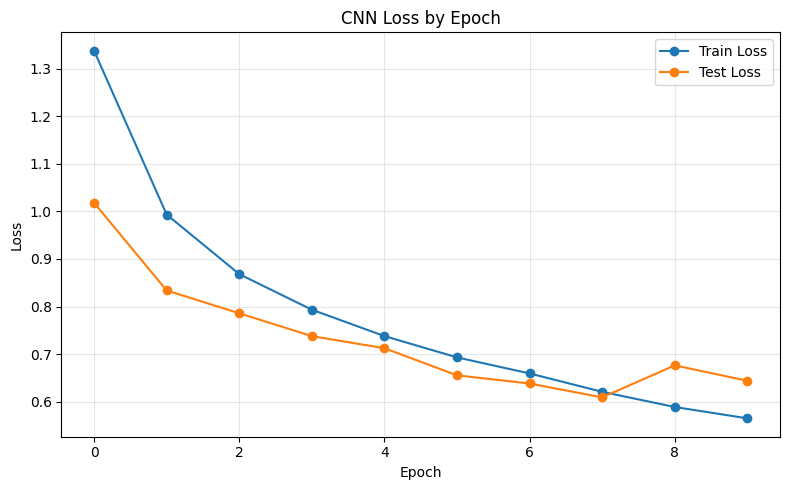

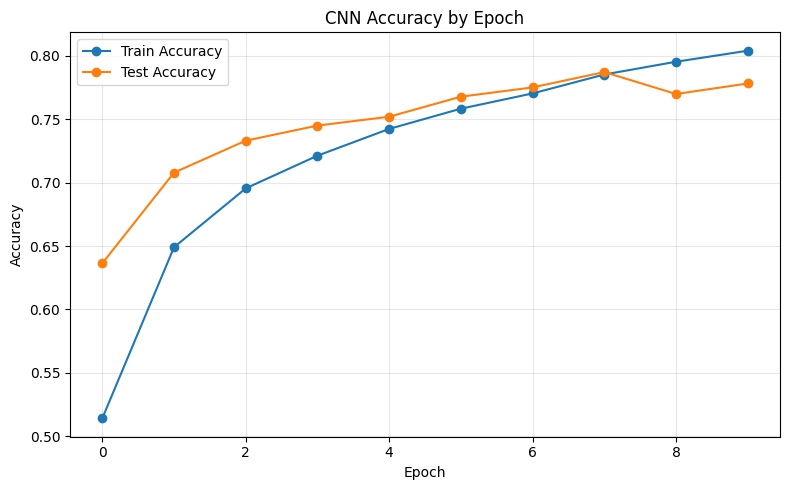

In [ ]:
def plot_metric(history, metric_key_train, metric_key_test, ylabel, title, save_path):
    plt.figure(figsize=(8, 5))
    plt.plot(history[metric_key_train], marker="o", label=f"Train {ylabel}")
    plt.plot(history[metric_key_test], marker="o", label=f"Test {ylabel}")
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()

plot_metric(cnn_history, "train_loss", "test_loss", "Loss", "CNN Loss by Epoch", OUTPUT_DIR / "cnn_loss_curve.png")
plot_metric(cnn_history, "train_acc", "test_acc", "Accuracy", "CNN Accuracy by Epoch", OUTPUT_DIR / "cnn_acc_curve.png")